In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

CUDA available: True
Device: Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import matplotlib.pyplot as plt

PROJECT_DIR = '/content/drive/MyDrive/gpr_fwi_diffusion'
os.chdir(PROJECT_DIR)
print("Working directory:", os.getcwd())
print("Drive mounted successfully.")

Mounted at /content/drive
Working directory: /content/drive/MyDrive/gpr_fwi_diffusion
Drive mounted successfully.


In [3]:
!pip install readgssi -q
import readgssi
print("readgssi installed successfully")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.4/67.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 88.2 MB/s eta 0:00:00
readgssi installed successfully


In [4]:
from google.colab import files
uploaded = files.upload()

Saving PROJECA000__001.DZT to PROJECA000__001.DZT


In [5]:
!pip install readgssi -q
from readgssi import readgssi
import numpy as np
import matplotlib.pyplot as plt

# Read the DZT file
header, data, gps = readgssi.readgssi(infile='PROJECA000__001.DZT', verbose=True)

2026-07-02 04:57:40 - reading...
2026-07-02 04:57:40 - input file:         PROJECA000__001.DZT
2026-07-02 04:57:40 - WARNING: no time zero specified for channel 0, defaulting to rh_zero value (1)
2026-07-02 04:57:40 - WARNING: no DZG file found for GPS input
2026-07-02 04:57:40 - WARNING: could not find DZX file to read metadata. Trying to read array for marks...
2026-07-02 04:57:40 - DZT marks read successfully. marks: 0
2026-07-02 04:57:40 -                             traces: []
2026-07-02 04:57:40 - success. header values:
2026-07-02 04:57:40 - system:             SIR 4000 (system code 8)
2026-07-02 04:57:40 - antennas:           ['50400S', None, None, None]
2026-07-02 04:57:40 - ant freqs. (MHz):   [400, None, None, None]
2026-07-02 04:57:40 - ant time zeros:     [1, None, None, None]
2026-07-02 04:57:40 - ant 0 center freq:  400 MHz
2026-07-02 04:57:40 - date created:       2021-01-07 13:40:10+00:00
2026-07-02 04:57:40 - date modified:      (never modified)
2026-07-02 04:57:40 - 

Data array shape: (1023, 29789)
Data range: -5686464.0 to 5378240.0


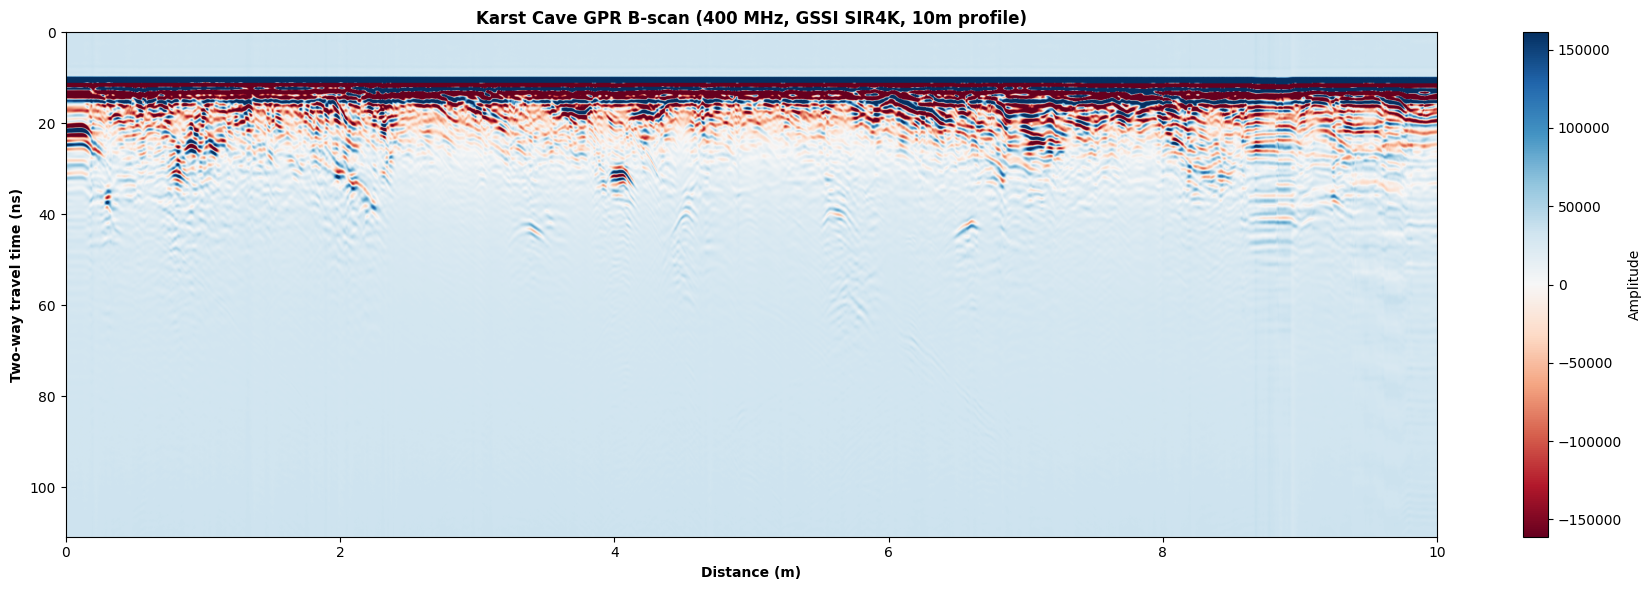

B-scan saved.


In [6]:
# Extract the data array
arr = data[0]  # channel 0
print(f"Data array shape: {arr.shape}")  # (1024 samples, 29789 traces)
print(f"Data range: {arr.min():.1f} to {arr.max():.1f}")

# Plot full B-scan (downsample traces for display)
step = 10  # show every 10th trace for speed
arr_ds = arr[:, ::step]

fig, ax = plt.subplots(figsize=(18, 6))
vmax = np.percentile(np.abs(arr_ds), 95)
ax.imshow(arr_ds, cmap='RdBu', aspect='auto',
          vmin=-vmax, vmax=vmax,
          extent=[0, 10, 110.9, 0])  # x=0-10m, y=0-110ns
ax.set_xlabel('Distance (m)', fontweight='bold')
ax.set_ylabel('Two-way travel time (ns)', fontweight='bold')
ax.set_title('Karst Cave GPR B-scan (400 MHz, GSSI SIR4K, 10m profile)',
             fontweight='bold')
plt.colorbar(ax.images[0], ax=ax, label='Amplitude')
plt.tight_layout()
plt.savefig('figure10_bscan_preview.png', dpi=150)
plt.show()
print("B-scan saved.")

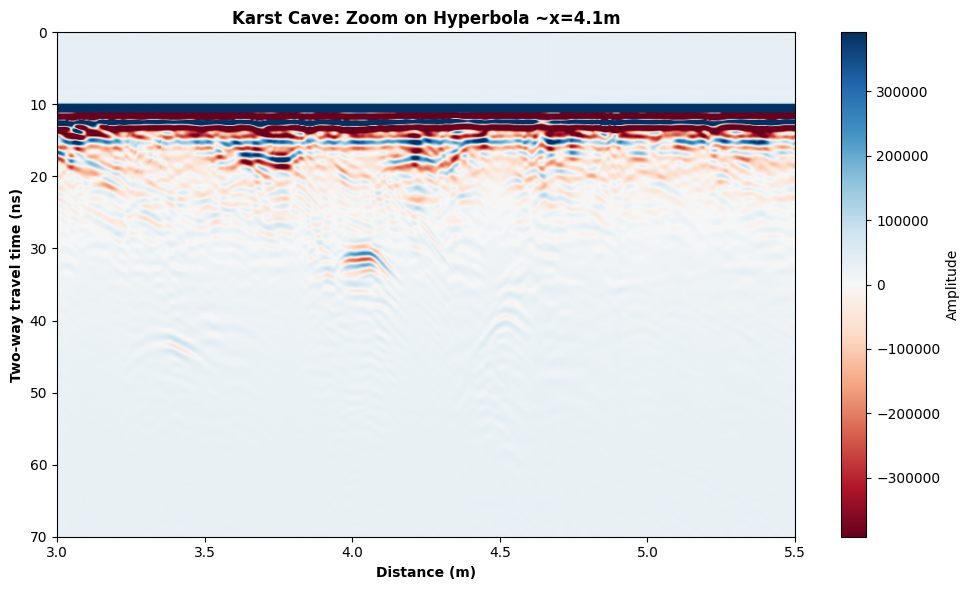

Estimated cave depth at x=4.1m: 1.52 m
Wave velocity in limestone (epsr=14): 8.02e+07 m/s


In [7]:
# Convert distance to trace number
# 29789 traces over 10m = 2978.9 traces/m
traces_per_m = 29789 / 10.0

# Zoom in: x=3.0m to x=5.5m, time 0-70ns
x_start = 3.0; x_end = 5.5
t_start_idx = 0; t_end_idx = int(70 / 110.9 * 1023)

tr_start = int(x_start * traces_per_m)
tr_end   = int(x_end   * traces_per_m)

arr_zoom = arr[t_start_idx:t_end_idx, tr_start:tr_end]
x_axis = np.linspace(x_start, x_end, arr_zoom.shape[1])
t_axis = np.linspace(0, 70, arr_zoom.shape[0])

fig, ax = plt.subplots(figsize=(10, 6))
vmax = np.percentile(np.abs(arr_zoom), 95)
ax.imshow(arr_zoom, cmap='RdBu', aspect='auto',
          vmin=-vmax, vmax=vmax,
          extent=[x_start, x_end, 70, 0])
ax.set_xlabel('Distance (m)', fontweight='bold')
ax.set_ylabel('Two-way travel time (ns)', fontweight='bold')
ax.set_title('Karst Cave: Zoom on Hyperbola ~x=4.1m',
             fontweight='bold')
plt.colorbar(ax.images[0], ax=ax, label='Amplitude')
plt.tight_layout()
plt.show()

# Also convert apex time to depth
# depth = v * t/2 = (c/sqrt(epsr)) * t/2
c = 3e8  # m/s
epsr = 14.0
v = c / np.sqrt(epsr)
apex_t_ns = 38  # approximate from visual inspection
depth_m = v * (apex_t_ns * 1e-9) / 2
print(f"Estimated cave depth at x=4.1m: {depth_m:.2f} m")
print(f"Wave velocity in limestone (epsr=14): {v:.2e} m/s")

Cave subset shape: (645, 8936)
Traces: 7447 to 16383 (8936 traces)
Background removed. Range: -1797080 to 2072324


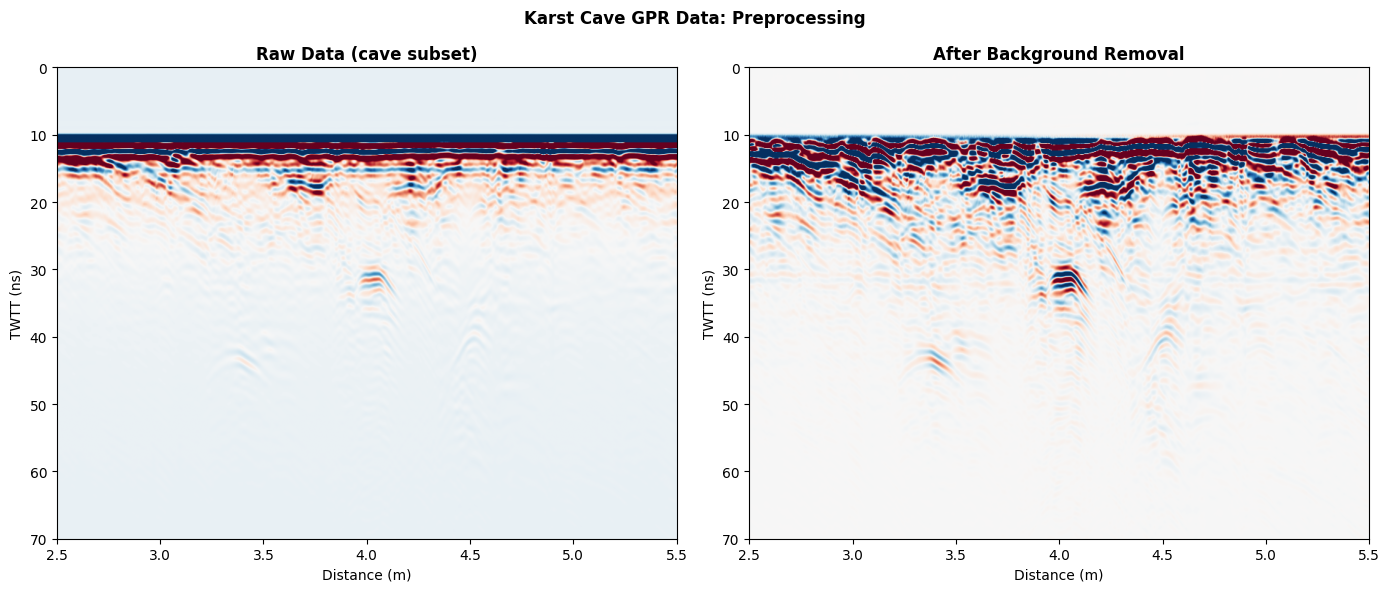

Cave data saved to Drive.
Cave depth estimate: 1.52m at x=4.0m


In [8]:
# Extract subset centered on the cave hyperbola
# x=2.5m to x=5.5m, time 0-70ns
x_start = 2.5; x_end = 5.5
t_end_ns = 70

tr_start = int(x_start * traces_per_m)
tr_end   = int(x_end   * traces_per_m)
t_end_idx = int(t_end_ns / 110.9 * 1023)

arr_cave = arr[0:t_end_idx, tr_start:tr_end].astype(np.float32)
print(f"Cave subset shape: {arr_cave.shape}")
print(f"Traces: {tr_start} to {tr_end} ({tr_end-tr_start} traces)")

# Background removal: subtract mean trace
mean_trace = arr_cave.mean(axis=1, keepdims=True)
arr_cave_proc = arr_cave - mean_trace
print(f"Background removed. Range: {arr_cave_proc.min():.0f} to {arr_cave_proc.max():.0f}")

# Time and distance axes
t_axis_ns = np.linspace(0, t_end_ns, arr_cave.shape[0])
x_axis_m  = np.linspace(x_start, x_end, arr_cave.shape[1])

# Plot raw vs processed side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
vmax_r = np.percentile(np.abs(arr_cave), 95)
vmax_p = np.percentile(np.abs(arr_cave_proc), 95)

axes[0].imshow(arr_cave, cmap='RdBu', aspect='auto',
               vmin=-vmax_r, vmax=vmax_r,
               extent=[x_start, x_end, t_end_ns, 0])
axes[0].set_title('Raw Data (cave subset)', fontweight='bold')
axes[0].set_xlabel('Distance (m)'); axes[0].set_ylabel('TWTT (ns)')

axes[1].imshow(arr_cave_proc, cmap='RdBu', aspect='auto',
               vmin=-vmax_p, vmax=vmax_p,
               extent=[x_start, x_end, t_end_ns, 0])
axes[1].set_title('After Background Removal', fontweight='bold')
axes[1].set_xlabel('Distance (m)'); axes[1].set_ylabel('TWTT (ns)')

plt.suptitle('Karst Cave GPR Data: Preprocessing', fontweight='bold')
plt.tight_layout()
plt.show()

# Save processed subset to Drive
np.save('karst_cave_data.npy',      arr_cave_proc)
np.save('karst_cave_t_axis.npy',    t_axis_ns)
np.save('karst_cave_x_axis.npy',    x_axis_m)
print("Cave data saved to Drive.")
print(f"Cave depth estimate: 1.52m at x=4.0m")

Windowed data: (349, 8936) (10.0-70.0 ns)
Final shape for inversion: (64, 32) (32 traces x 64 samples)
Lateral coverage: 2.50m to 5.50m
Amplitude range: -1514563.4 to 1649788.6


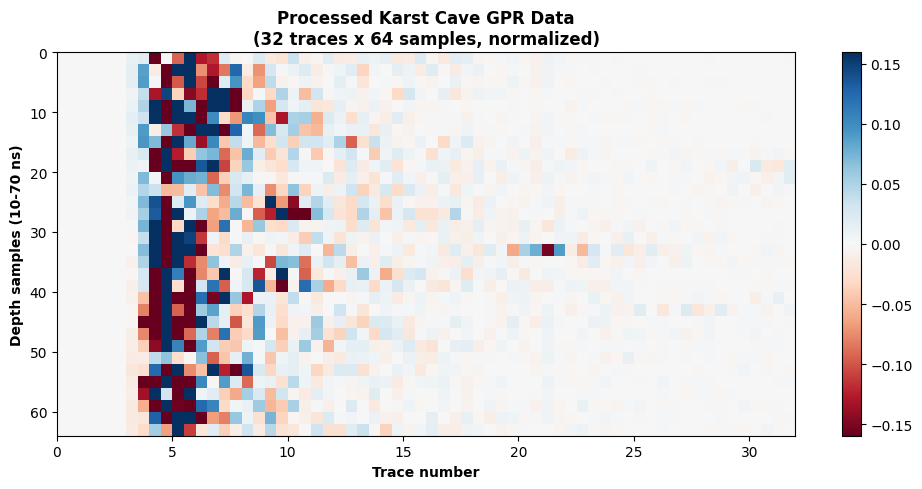

Processed karst data saved to Drive.


In [9]:
from scipy.interpolate import interp1d

# Resample to 64 depth samples for consistency with inversion grid
# Use only the meaningful window: 10-70ns (skip direct wave above 10ns)
t_window_start_ns = 10.0
t_window_end_ns   = 70.0

# Find indices
idx_start = int(t_window_start_ns / 110.9 * arr_cave_proc.shape[0])
idx_end   = int(t_window_end_ns   / 110.9 * arr_cave_proc.shape[0])

arr_windowed = arr_cave_proc[idx_start:idx_end, :]
t_windowed   = t_axis_ns[idx_start:idx_end]
print(f"Windowed data: {arr_windowed.shape} ({t_window_start_ns}-{t_window_end_ns} ns)")

# Resample to 64 time samples
n_out = 64
t_old = np.linspace(0, 1, arr_windowed.shape[0])
t_new = np.linspace(0, 1, n_out)
arr_64 = np.zeros((n_out, arr_windowed.shape[1]), dtype=np.float32)
for i in range(arr_windowed.shape[1]):
    f = interp1d(t_old, arr_windowed[:, i], kind='linear')
    arr_64[:, i] = f(t_new)

# Downsample to 32 traces (consistent with all other figures)
trace_idx = np.linspace(0, arr_64.shape[1]-1, 32, dtype=int)
arr_32 = arr_64[:, trace_idx]
x_32   = x_axis_m[trace_idx]

print(f"Final shape for inversion: {arr_32.shape} (32 traces x 64 samples)")
print(f"Lateral coverage: {x_32[0]:.2f}m to {x_32[-1]:.2f}m")
print(f"Amplitude range: {arr_32.min():.1f} to {arr_32.max():.1f}")

# Normalize to unit amplitude (same scale as synthetic data)
arr_32_norm = arr_32 / np.max(np.abs(arr_32))

# Plot final processed data
fig, ax = plt.subplots(figsize=(10, 5))
vmax = np.percentile(np.abs(arr_32_norm), 95)
ax.imshow(arr_32_norm.T, cmap='RdBu', aspect='auto',
          vmin=-vmax, vmax=vmax,
          extent=[0, 32, 64, 0])
ax.set_xlabel('Trace number', fontweight='bold')
ax.set_ylabel('Depth samples (10-70 ns)', fontweight='bold')
ax.set_title('Processed Karst Cave GPR Data\n(32 traces x 64 samples, normalized)',
             fontweight='bold')
plt.colorbar(ax.images[0], ax=ax)
plt.tight_layout()
plt.show()

# Save to Drive
np.save('karst_obs_32x64.npy',  arr_32_norm)
np.save('karst_x_axis_32.npy',  x_32)
print("Processed karst data saved to Drive.")

Re-centered subset: (349, 4766)
Lateral coverage: 3.2m to 4.8m
Final shape: (64, 32)
Amplitude range: -0.841 to 1.000


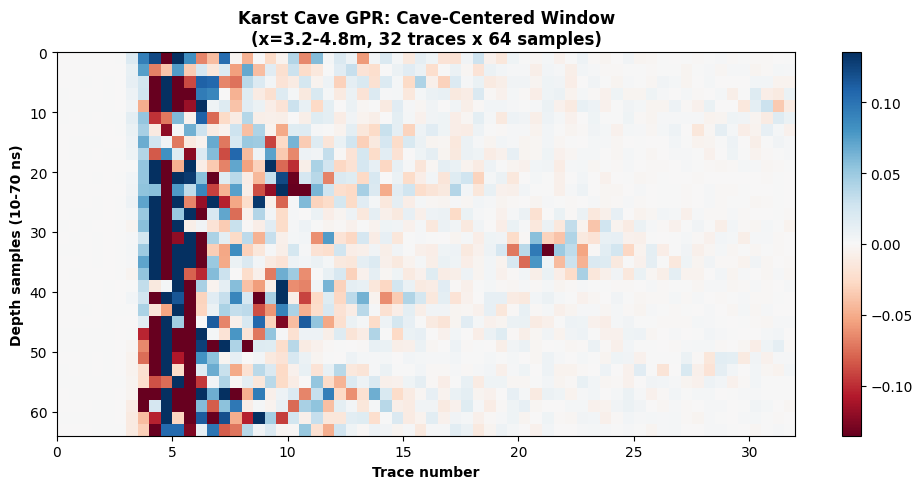

Cave-centered data saved to Drive.


In [10]:
# Re-center window tightly around the cave at x=4.0m
# Use x=3.2m to x=4.8m (1.6m window, cave centered)
x_start2 = 3.2; x_end2 = 4.8

tr_start2 = int(x_start2 * traces_per_m)
tr_end2   = int(x_end2   * traces_per_m)

# Re-extract from processed data
arr_cave2 = arr_cave_proc[idx_start:idx_end,
                          tr_start2-tr_start:tr_end2-tr_start]

print(f"Re-centered subset: {arr_cave2.shape}")
print(f"Lateral coverage: {x_start2}m to {x_end2}m")

# Resample to 32 traces x 64 depth samples
n_traces_out = 32
n_depth_out  = 64

t_old = np.linspace(0, 1, arr_cave2.shape[0])
t_new = np.linspace(0, 1, n_depth_out)
trace_idx2 = np.linspace(0, arr_cave2.shape[1]-1, n_traces_out, dtype=int)

arr_final = np.zeros((n_depth_out, n_traces_out), dtype=np.float32)
for i, ti in enumerate(trace_idx2):
    f = interp1d(t_old, arr_cave2[:, ti], kind='linear')
    arr_final[:, i] = f(t_new)

x_final = np.linspace(x_start2, x_end2, n_traces_out)

# Normalize
arr_final_norm = arr_final / (np.max(np.abs(arr_final)) + 1e-10)

print(f"Final shape: {arr_final_norm.shape}")
print(f"Amplitude range: {arr_final_norm.min():.3f} to {arr_final_norm.max():.3f}")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
vmax = np.percentile(np.abs(arr_final_norm), 95)
im = ax.imshow(arr_final_norm.T, cmap='RdBu', aspect='auto',
               vmin=-vmax, vmax=vmax,
               extent=[0, 32, 64, 0])
ax.set_xlabel('Trace number', fontweight='bold')
ax.set_ylabel('Depth samples (10-70 ns)', fontweight='bold')
ax.set_title('Karst Cave GPR: Cave-Centered Window\n'
             f'(x={x_start2}-{x_end2}m, 32 traces x 64 samples)',
             fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

# Save updated version to Drive
np.save('karst_obs_centered.npy', arr_final_norm)
np.save('karst_x_centered.npy',   x_final)
print("Cave-centered data saved to Drive.")

Peak energy trace: 6373
Cave center position: x = 4.640 m
Re-extracted shape: (349, 4766)
Lateral coverage: 3.84m to 5.44m


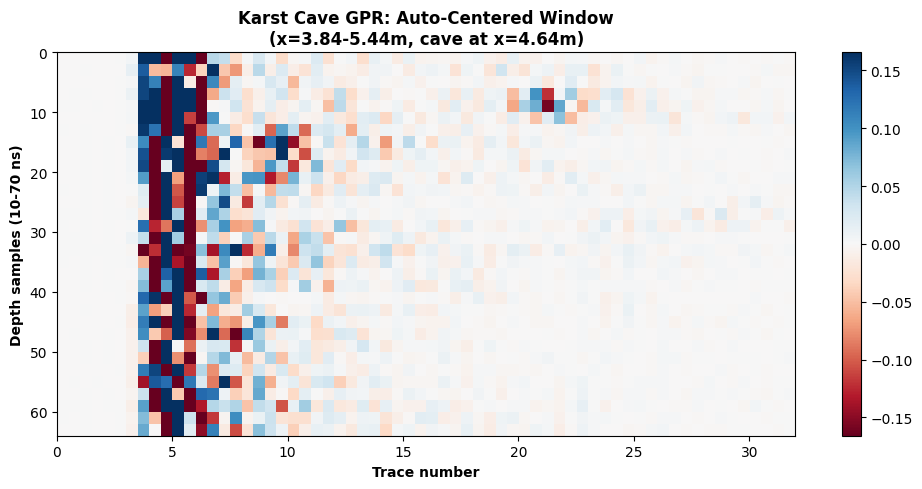

Final karst data saved. Cave at x=4.640m


In [11]:
# Find exact cave location by picking the peak amplitude trace
# in the depth window where the hyperbola apex should be
# (depth samples 20-40, corresponding to ~30-45ns)

peak_energy = np.sum(arr_cave_proc[idx_start:idx_end, :]**2, axis=0)
cave_trace_idx = np.argmax(peak_energy)
cave_x = x_axis_m[cave_trace_idx] if cave_trace_idx < len(x_axis_m) else x_start + cave_trace_idx / traces_per_m

# Recalculate absolute position
cave_x_abs = x_start + cave_trace_idx * (x_end - x_start) / arr_cave_proc.shape[1]
print(f"Peak energy trace: {cave_trace_idx}")
print(f"Cave center position: x = {cave_x_abs:.3f} m")

# Re-extract centered on actual cave position
half_window = 0.8  # 1.6m total window
x_c_start = max(0, cave_x_abs - half_window)
x_c_end   = min(10, cave_x_abs + half_window)

tr_c_start = int(x_c_start * traces_per_m)
tr_c_end   = int(x_c_end   * traces_per_m)

# Extract from full processed array (not just cave subset)
arr_full_proc = arr[0:t_end_idx, :] - arr[0:t_end_idx, :].mean(axis=1, keepdims=True)
arr_window = arr_full_proc[idx_start:idx_end, tr_c_start:tr_c_end]

print(f"Re-extracted shape: {arr_window.shape}")
print(f"Lateral coverage: {x_c_start:.2f}m to {x_c_end:.2f}m")

# Resample to 32 traces x 64 depth samples
from scipy.interpolate import interp1d
n_traces_out = 32
n_depth_out  = 64

t_old = np.linspace(0, 1, arr_window.shape[0])
t_new = np.linspace(0, 1, n_depth_out)
trace_idx_new = np.linspace(0, arr_window.shape[1]-1, n_traces_out, dtype=int)

arr_resampled = np.zeros((n_depth_out, n_traces_out), dtype=np.float32)
for i, ti in enumerate(trace_idx_new):
    f = interp1d(t_old, arr_window[:, ti], kind='linear')
    arr_resampled[:, i] = f(t_new)

# Normalize
arr_resampled_norm = arr_resampled / (np.max(np.abs(arr_resampled)) + 1e-10)
x_resampled = np.linspace(x_c_start, x_c_end, n_traces_out)

fig, ax = plt.subplots(figsize=(10, 5))
vmax = np.percentile(np.abs(arr_resampled_norm), 95)
im = ax.imshow(arr_resampled_norm.T, cmap='RdBu', aspect='auto',
               vmin=-vmax, vmax=vmax,
               extent=[0, 32, 64, 0])
ax.set_xlabel('Trace number', fontweight='bold')
ax.set_ylabel('Depth samples (10-70 ns)', fontweight='bold')
ax.set_title(f'Karst Cave GPR: Auto-Centered Window\n'
             f'(x={x_c_start:.2f}-{x_c_end:.2f}m, cave at x={cave_x_abs:.2f}m)',
             fontweight='bold')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

np.save('karst_obs_final.npy', arr_resampled_norm)
np.save('karst_x_final.npy',   x_resampled)
print(f"Final karst data saved. Cave at x={cave_x_abs:.3f}m")

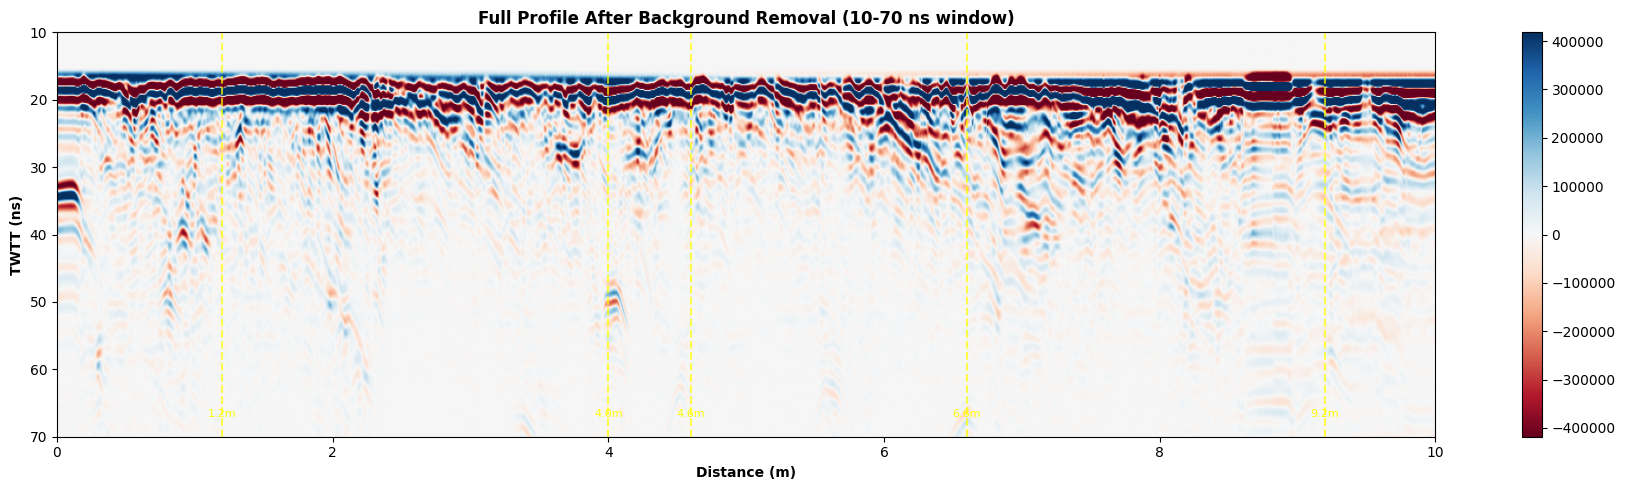

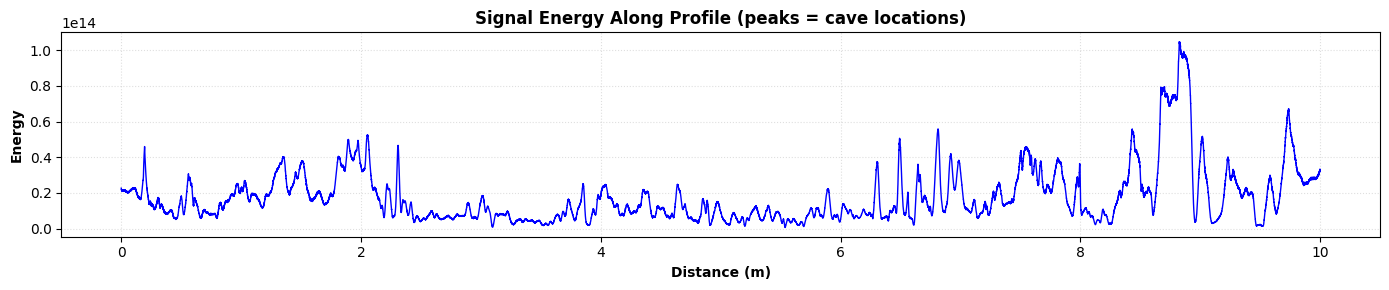

Done. Yellow lines mark candidate cave positions.


In [12]:
# Plot the full B-scan with proper axes to find exact cave position
# Use the full processed array directly without downsampling
fig, ax = plt.subplots(figsize=(18, 5))

# Use every 5th trace for display speed
step = 5
arr_display = arr_full_proc[:, ::step]
x_display = np.linspace(0, 10, arr_display.shape[1])
t_display = np.linspace(0, 110.9, arr_display.shape[0])

vmax = np.percentile(np.abs(arr_display[idx_start:idx_end, :]), 95)
ax.imshow(arr_display[idx_start:idx_end, :], cmap='RdBu', aspect='auto',
          vmin=-vmax, vmax=vmax,
          extent=[0, 10, t_window_end_ns, t_window_start_ns])
ax.set_xlabel('Distance (m)', fontweight='bold')
ax.set_ylabel('TWTT (ns)', fontweight='bold')
ax.set_title('Full Profile After Background Removal (10-70 ns window)',
             fontweight='bold')
plt.colorbar(ax.images[0], ax=ax)

# Add vertical lines at candidate cave positions
for x_cand in [1.2, 4.0, 4.6, 6.6, 9.2]:
    ax.axvline(x=x_cand, color='yellow', lw=1.5, ls='--', alpha=0.7)
    ax.text(x_cand, t_window_end_ns-3, f'{x_cand}m',
            color='yellow', fontsize=8, ha='center')

plt.tight_layout()
plt.show()

# Also plot energy profile along the profile
energy_profile = np.sum(arr_full_proc[idx_start:idx_end, :]**2, axis=0)
x_all = np.linspace(0, 10, len(energy_profile))

fig2, ax2 = plt.subplots(figsize=(14, 3))
ax2.plot(x_all, energy_profile, 'b-', lw=1)
ax2.set_xlabel('Distance (m)', fontweight='bold')
ax2.set_ylabel('Energy', fontweight='bold')
ax2.set_title('Signal Energy Along Profile (peaks = cave locations)',
              fontweight='bold')
ax2.grid(True, ls=':', alpha=0.4)
plt.tight_layout()
plt.show()

print("Done. Yellow lines mark candidate cave positions.")

Deep subset shape: (323, 7447)
Time window: 35.0-70.0 ns
Lateral: 3.0-5.5 m


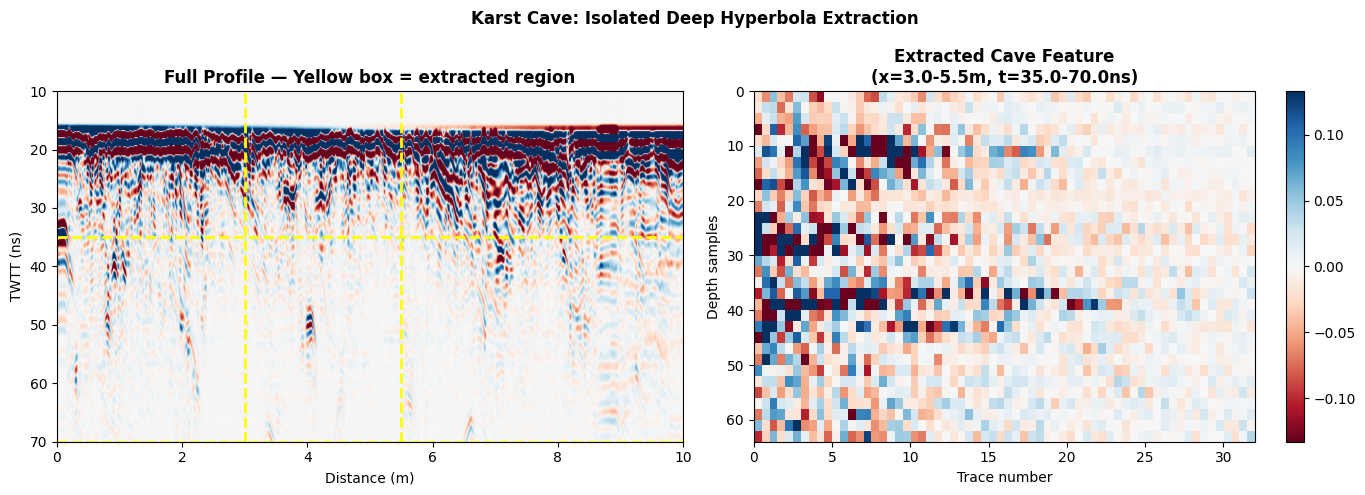

Deep feature saved to Drive.


In [13]:
# Target the isolated hyperbola at x≈4.0m, t≈50ns
# This is below the main karst reflection band (which ends ~35ns)
# Time window: 35-70ns (below the noisy upper zone)
t_deep_start_ns = 35.0
t_deep_end_ns   = 70.0

idx_deep_start = int(t_deep_start_ns / 110.9 * arr.shape[0])
idx_deep_end   = int(t_deep_end_ns   / 110.9 * arr.shape[0])

# Lateral window: x=3.0m to x=5.5m centered on the isolated feature
x_deep_start = 3.0; x_deep_end = 5.5
tr_deep_start = int(x_deep_start * traces_per_m)
tr_deep_end   = int(x_deep_end   * traces_per_m)

# Extract from full background-removed array
arr_deep = arr_full_proc[idx_deep_start:idx_deep_end,
                         tr_deep_start:tr_deep_end]

print(f"Deep subset shape: {arr_deep.shape}")
print(f"Time window: {t_deep_start_ns}-{t_deep_end_ns} ns")
print(f"Lateral: {x_deep_start}-{x_deep_end} m")

# Resample to 32 x 64
from scipy.interpolate import interp1d
arr_deep_out = np.zeros((64, 32), dtype=np.float32)
t_old = np.linspace(0, 1, arr_deep.shape[0])
t_new = np.linspace(0, 1, 64)
tr_idx = np.linspace(0, arr_deep.shape[1]-1, 32, dtype=int)

for i, ti in enumerate(tr_idx):
    f = interp1d(t_old, arr_deep[:, ti], kind='linear')
    arr_deep_out[:, i] = f(t_new)

arr_deep_norm = arr_deep_out / (np.max(np.abs(arr_deep_out)) + 1e-10)
x_deep = np.linspace(x_deep_start, x_deep_end, 32)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Full B-scan with box showing extracted region
vmax_full = np.percentile(np.abs(arr_full_proc), 95)
axes[0].imshow(arr_full_proc[idx_start:idx_end, ::5],
               cmap='RdBu', aspect='auto', vmin=-vmax_full, vmax=vmax_full,
               extent=[0, 10, t_window_end_ns, t_window_start_ns])
axes[0].axhline(y=t_deep_start_ns, color='yellow', lw=2, ls='--')
axes[0].axhline(y=t_deep_end_ns,   color='yellow', lw=2, ls='--')
axes[0].axvline(x=x_deep_start, color='yellow', lw=2, ls='--')
axes[0].axvline(x=x_deep_end,   color='yellow', lw=2, ls='--')
axes[0].set_title('Full Profile — Yellow box = extracted region',
                   fontweight='bold')
axes[0].set_xlabel('Distance (m)'); axes[0].set_ylabel('TWTT (ns)')

# Extracted deep feature
vmax_d = np.percentile(np.abs(arr_deep_norm), 95)
im = axes[1].imshow(arr_deep_norm.T, cmap='RdBu', aspect='auto',
                    vmin=-vmax_d, vmax=vmax_d,
                    extent=[0, 32, 64, 0])
axes[1].set_title(f'Extracted Cave Feature\n(x={x_deep_start}-{x_deep_end}m, '
                  f't={t_deep_start_ns}-{t_deep_end_ns}ns)',
                  fontweight='bold')
axes[1].set_xlabel('Trace number')
axes[1].set_ylabel('Depth samples')
plt.colorbar(im, ax=axes[1])

plt.suptitle('Karst Cave: Isolated Deep Hyperbola Extraction',
             fontweight='bold')
plt.tight_layout()
plt.show()

np.save('karst_deep_feature.npy', arr_deep_norm)
np.save('karst_deep_x.npy', x_deep)
print("Deep feature saved to Drive.")